## EXO - ESTIMATION D'UNE FREQUENCE COMPLEXE

In [2]:
# Librairies à importer

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

In [3]:
#  PARAMÈTRES

A      = 1.0
phi    = 0.5
omega0_ref = 1.0  # Pulsation de référence
N      = 20
N_MC   = 300
SNR_dB = 10.0

# Grille de recherche pour l'EMV (Périodogramme)
omega_grid = np.linspace(-np.pi, np.pi, 1000)

In [37]:
#  FONCTIONS

def generer_signal(N, omega_true, sigma):
    n     = np.arange(N)
    s     = A * np.exp(1j * (n * omega_true + phi))
    bruit = (sigma / np.sqrt(2)) * (np.random.randn(N) + 1j * np.random.randn(N))
    return s + bruit

def estimer_omega(x):
    n = np.arange(len(x))
    
    # -- Partie 1 : Recherche sur grille --
    # On projette sur la phase connue : on multiplie par exp(-1j * phi)
    # puis on prend la partie réelle.
    projection = np.dot(x, np.exp(-1j * np.outer(n, omega_grid)))
    vals = np.real(np.exp(-1j * phi) * projection)
    
    idx_max = np.argmax(vals)
    omega_initial = omega_grid[idx_max]

    # -- Partie 2 : Raffinement --
    def objective(w):
        # On maximise la partie réelle projetée
        # (On met un signe moins car on utilise un minimiseur)
        return -np.real(np.exp(-1j * phi) * np.sum(x * np.exp(-1j * n * w)))
    
    pas = (omega_grid[1] - omega_grid[0])
    res = minimize_scalar(objective, 
                          bounds=(omega_initial - pas, omega_initial + pas), 
                          method='bounded')
    return res.x

def estimer_phi(x, omega):
    n = np.arange(len(x))
    projection = np.sum(x * np.exp(-1j * n * omega))
    return np.angle(projection)

def BCR(N, sigma):
    somme_n2 = (N - 1) * N * (2 * N - 1) / 6
    return (sigma**2) / (2 * (A**2) * somme_n2)

def monte_carlo(N, omega_true, sigma):
    estimations = []
    for _ in range(N_MC):
        x = generer_signal(N, omega_true, sigma)
        omega_hat = estimer_omega(x)
        estimations.append(omega_hat)

    estimations = np.array(estimations)
    biais       = np.mean(estimations) - omega_true
    variance    = np.var(estimations)
    mse         = np.mean((estimations - omega_true) ** 2)
    return biais, variance, mse

def tracer(ax, x, y, bcr, xlabel, ylabel, title):
    ax.semilogy(x, y,   'o-', label=ylabel)
    if np.isscalar(bcr):
        ax.axhline(y=bcr, color='r', linestyle='--', label='BCR')
    else:
        ax.semilogy(x, bcr, 'r--', label='BCR')
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, which='both', alpha=0.4)

def mce_theo_pulsation(bcr_classique):
    # bcr_classique est la valeur sigma^2 / (2 * N * A^2) ou celle de omega
    return 2 - (2 / np.sqrt(1 + bcr_classique))

def estimer_signal_complet(x):
    n = np.arange(len(x))
    
    # 1. On récupère la pulsation (ton code existant)
    omega_hat = estimer_omega(x)
    
    # 2. Estimation conjointe de A et phi via la projection complexe
    projection = np.mean(x * np.exp(-1j * n * omega_hat))
    
    A_hat = np.abs(projection)
    phi_hat = np.angle(projection)
    
    # 3. Reconstruction du signal
    s_hat = A_hat * np.exp(1j * (n * omega_hat + phi_hat))
    
    return s_hat, (A_hat, omega_hat, phi_hat)



Sweep SNR...


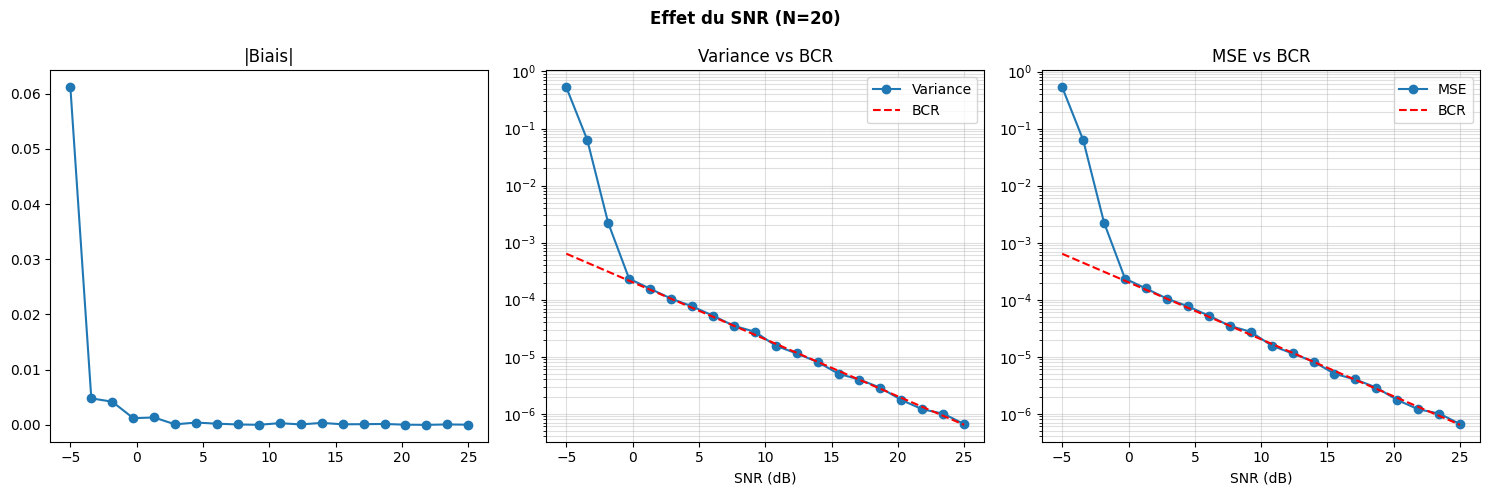

In [38]:
# Premier tracé

SNR_dB_values = np.linspace(-5, 25, 20)
biais_snr, variance_snr, mse_snr, bcr_snr = [], [], [], []

print("Sweep SNR...")
for snr_db in SNR_dB_values:
    snr   = 10 ** (snr_db / 10)
    sigma = np.sqrt(A**2 / snr)
    b, v, m = monte_carlo(N, omega0_ref, sigma)
    biais_snr.append(abs(b))
    variance_snr.append(v)
    mse_snr.append(m)
    bcr_snr.append(BCR(N, sigma))

fig1, axes1 = plt.subplots(1, 3, figsize=(15, 5))
fig1.suptitle(f"Effet du SNR (N={N})", fontweight='bold')

axes1[0].plot(SNR_dB_values, biais_snr, 'o-')
axes1[0].set_title("|Biais|")

tracer(axes1[1], SNR_dB_values, variance_snr, bcr_snr, "SNR (dB)", "Variance", "Variance vs BCR")
tracer(axes1[2], SNR_dB_values, mse_snr, bcr_snr, "SNR (dB)", "MSE", "MSE vs BCR")

fig1.tight_layout()
plt.show() 

Sweep N...


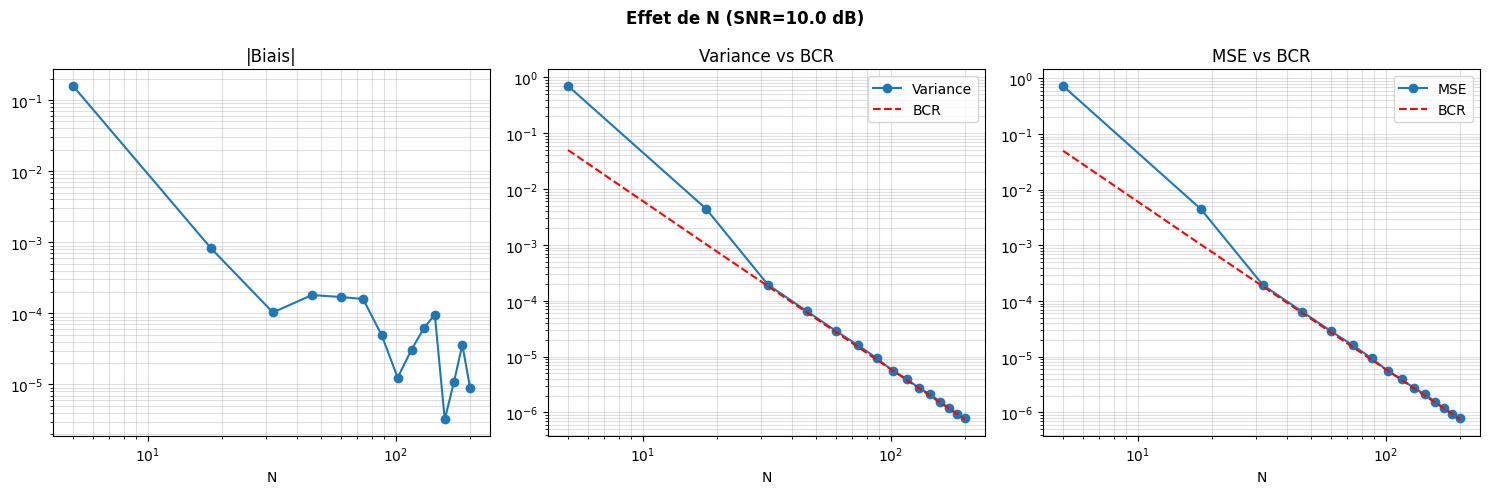

In [5]:
# Deuxième tracé

N_values = np.unique(np.linspace(5, 200, 15).astype(int))

snr_ref_N  = 10 ** (0 / 10)
sigma_ref_N = np.sqrt(A**2 / snr_ref_N)
biais_N, variance_N, mse_N, bcr_N = [], [], [], []

print("Sweep N...")
for Nv in N_values:
   
    b, v, m = monte_carlo(Nv, omega0_ref, sigma_ref_N)
    biais_N.append(abs(b))
    variance_N.append(v)
    mse_N.append(m)
    bcr_N.append(BCR(Nv, sigma_ref_N))

# -- Visualisation --
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))
fig2.suptitle(f"Effet de N (SNR={SNR_dB} dB)", fontweight='bold')

# Biais en log-log
axes2[0].loglog(N_values, biais_N, 'o-', label="|Biais|")
axes2[0].set_title("|Biais|")
axes2[0].set_xlabel("N")
axes2[0].grid(True, which='both', alpha=0.4)

# Variance vs BCR en log-log
tracer(axes2[1], N_values, variance_N, bcr_N, "N", "Variance", "Variance vs BCR")
axes2[1].set_xscale('log') 
axes2[1].set_yscale('log') 

# MSE vs BCR en log-log
tracer(axes2[2], N_values, mse_N, bcr_N, "N", "MSE", "MSE vs BCR")
axes2[2].set_xscale('log')
axes2[2].set_yscale('log')

fig2.tight_layout()
plt.show()

Sweep Omega (SNR = 5 dB)...


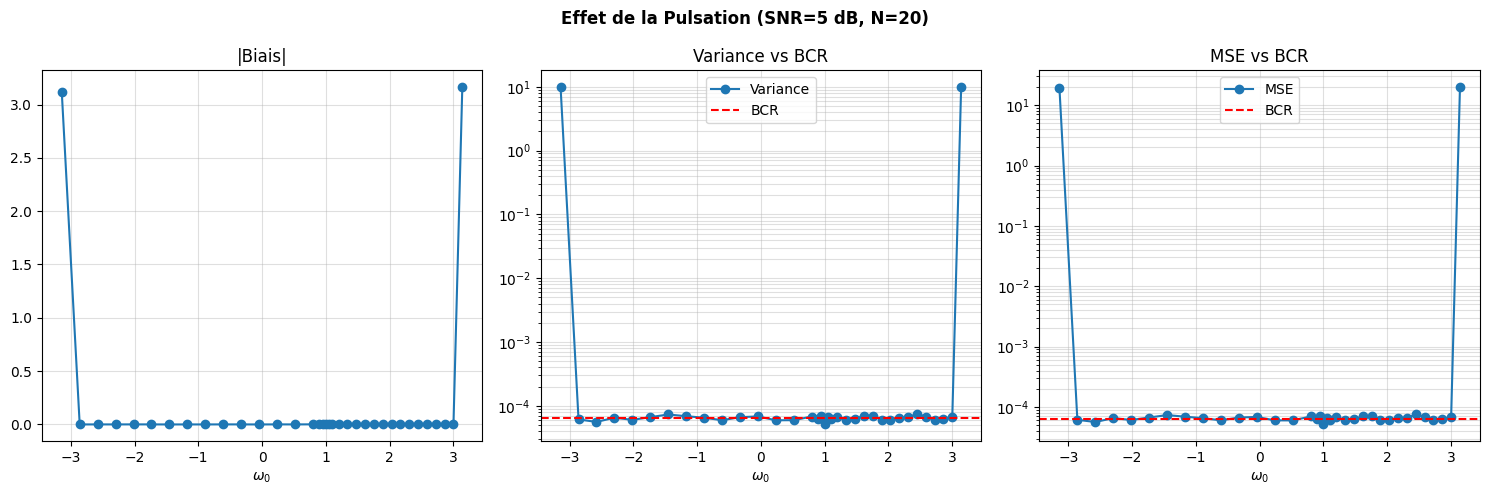

In [39]:
# Troisème tracé

omega_values = np.concatenate([
    np.linspace(-np.pi, 0.8, 15),
    np.linspace(0.9, 1.1, 5), 
    np.linspace(1.2, np.pi, 15)
])
omega_values = np.sort(omega_values)

snr_ref_W = 10 ** (5 / 10) # SNR fixé à 5 dB
sigma_ref_W = np.sqrt(A**2 / snr_ref_W)
biais_W, variance_W, mse_W, bcr_val = [], [], [], BCR(N, sigma_ref_W)

print("Sweep Omega (SNR = 5 dB)...")
for wv in omega_values:
    b, v, m = monte_carlo(N, wv, sigma_ref_W)
    biais_W.append(abs(b))
    variance_W.append(v)
    mse_W.append(m)
fig3, axes3 = plt.subplots(1, 3, figsize=(15, 5))
fig3.suptitle(f"Effet de la Pulsation (SNR=5 dB, N={N})", fontweight='bold')

# Affichage du Biais
axes3[0].plot(omega_values, biais_W, 'o-')
axes3[0].set_title("|Biais|")
axes3[0].set_xlabel(r"$\omega_0$")
axes3[0].grid(True, alpha=0.4)

# Variance vs BCR
tracer(axes3[1], omega_values, variance_W, bcr_val, r"$\omega_0$", "Variance", "Variance vs BCR")

# MSE vs BCR
tracer(axes3[2], omega_values, mse_W, bcr_val, r"$\omega_0$", "MSE", "MSE vs BCR")

fig3.tight_layout()
plt.show() # Affiche la figure directement sous la cellule


Calcul de la MSE


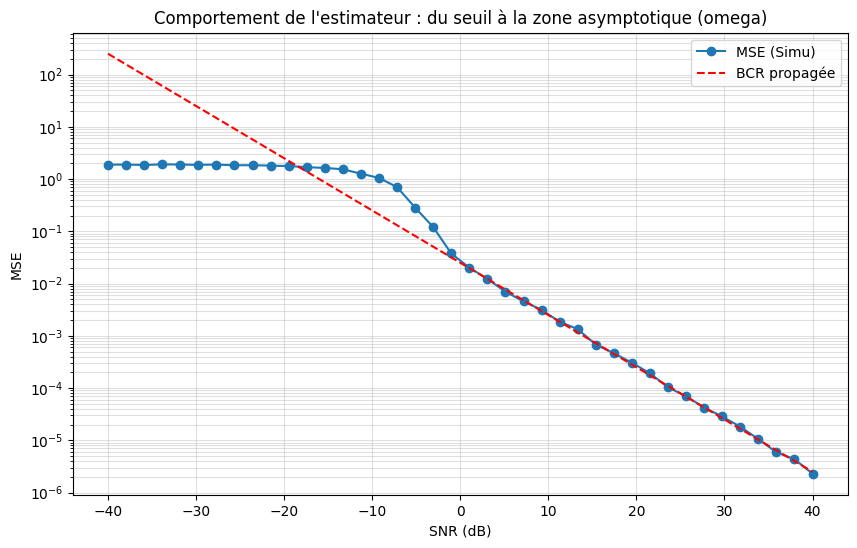

In [44]:
#  MSE DE RECONSTRUCTION 

SNR_dB_range = np.linspace(-40, 40, 40) 
mse_estimation_pure = []
bcr_propagation_signal = []

print("Calcul de la MSE")

for snr_db in SNR_dB_range:
    snr = 10 ** (snr_db / 10)
    sigma = np.sqrt(A**2 / snr)
    
    errors_iter = []
    n = np.arange(N)
    s_vrai = A * np.exp(1j * (n * omega0_ref + phi))
    
    for _ in range(N_MC):
        x = generer_signal(N, omega0_ref, sigma)
        omega_hat = estimer_omega(x)
        

        s_hat = A * np.exp(1j * (n * omega_hat + phi))
        errors_iter.append(np.mean(np.abs(s_vrai - s_hat)**2))
    
    mse_estimation_pure.append(np.mean(errors_iter))
    

    borne_sig = sigma**2 / (2*N)

    bcr_propagation_signal.append(borne_sig)

# --- Affichage ---
fig5, ax5 = plt.subplots(1, 1, figsize=(10, 6))
ax5.semilogy(SNR_dB_range, mse_estimation_pure, 'o-', label="MSE (Simu)")
ax5.semilogy(SNR_dB_range, bcr_propagation_signal, 'r--', label="BCR propagée")


ax5.set_xlabel("SNR (dB)")
ax5.set_ylabel("MSE")
ax5.set_title("Comportement de l'estimateur : du seuil à la zone asymptotique (omega)")
ax5.legend()
ax5.grid(True, which='both', alpha=0.4)

plt.show()

Calcul de la MCE du signal en cours...


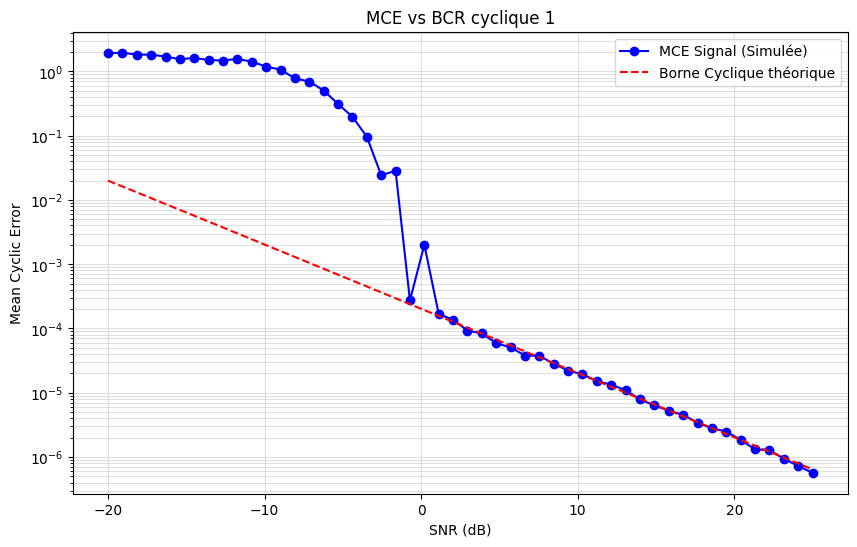

In [45]:
# Tracé de la MCE et de la BCR cyclique 1 pour l'estimation de la pulsation

SNR_dB_range = np.linspace(-20, 25, 50) 

mce_simu_sig = []
borne_cyclique_sig = []

print("Calcul de la MCE du signal en cours...")

for snr_db in SNR_dB_range:
    snr = 10 ** (snr_db / 10)
    sigma = np.sqrt(A**2 / snr)
    
    errors_iter = []
    n = np.arange(N)

    s_vrai = A * np.exp(1j * (n * omega0_ref + phi))
    
    for _ in range(N_MC):

        x = generer_signal(N, omega0_ref, sigma)
        omega_hat = estimer_omega(x)
        

        s_hat = A * np.exp(1j * (n * omega_hat + phi))
        
        dist_sq = np.mean(np.abs(s_vrai - s_hat)**2)

        mce = np.mean(2 * (1 - np.cos(omega_hat - omega0_ref)))

        errors_iter.append(mce)
        
    
    mce_simu_sig.append(np.mean(errors_iter))
    

    
    bcr_omega = BCR(N,sigma)
    bcr_cyclique = 2 - 2 / np.sqrt(1 + bcr_omega)


    borne_cyclique_sig.append(bcr_cyclique)

# --- Affichage ---
plt.figure(figsize=(10, 6))
plt.semilogy(SNR_dB_range, mce_simu_sig, 'bo-', label='MCE Signal (Simulée)')
plt.semilogy(SNR_dB_range, borne_cyclique_sig, 'r--', label='Borne Cyclique théorique')

plt.xlabel('SNR (dB)')
plt.ylabel('Mean Cyclic Error')
plt.title('MCE vs BCR cyclique 1')
plt.grid(True, which='both', alpha=0.4)
plt.legend()
plt.show()

Calcul de la MSE


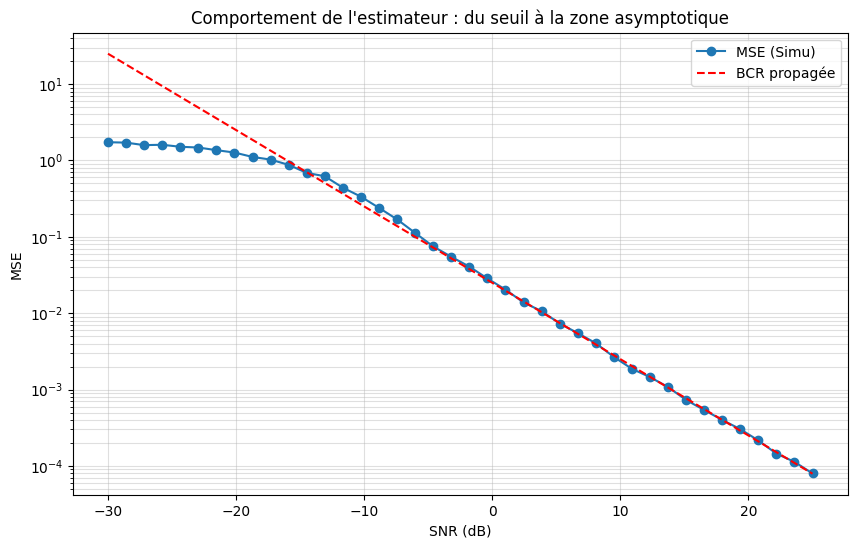

In [14]:
#  MSE DE RECONSTRUCTION 

SNR_dB_range = np.linspace(-30, 25, 40) 
mse_estimation_pure = []
bcr_propagation_signal = []

print("Calcul de la MSE")

for snr_db in SNR_dB_range:
    snr = 10 ** (snr_db / 10)
    sigma = np.sqrt(A**2 / snr)
    
    errors_iter = []
    n = np.arange(N)
    s_vrai = A * np.exp(1j * (n * omega0_ref + phi))
    
    for _ in range(N_MC):
        x = generer_signal(N, omega0_ref, sigma)
        phi_hat = estimer_phi(x, omega0_ref)
        

        s_hat = A * np.exp(1j * (n * omega0_ref + phi_hat))
        errors_iter.append(np.mean(np.abs(s_vrai - s_hat)**2))
    
    mse_estimation_pure.append(np.mean(errors_iter))
    
    borne_propagee = (sigma**2) / (2*N)
    bcr_propagation_signal.append(borne_propagee)

# --- Affichage ---
fig6, ax6 = plt.subplots(1, 1, figsize=(10, 6))
ax6.semilogy(SNR_dB_range, mse_estimation_pure, 'o-', label="MSE (Simu)")
ax6.semilogy(SNR_dB_range, bcr_propagation_signal, 'r--', label="BCR propagée")


ax6.set_xlabel("SNR (dB)")
ax6.set_ylabel("MSE")
ax6.set_title("Comportement de l'estimateur : du seuil à la zone asymptotique")
ax6.legend()
ax6.grid(True, which='both', alpha=0.4)

plt.show()

Calcul de la MCE du signal en cours...


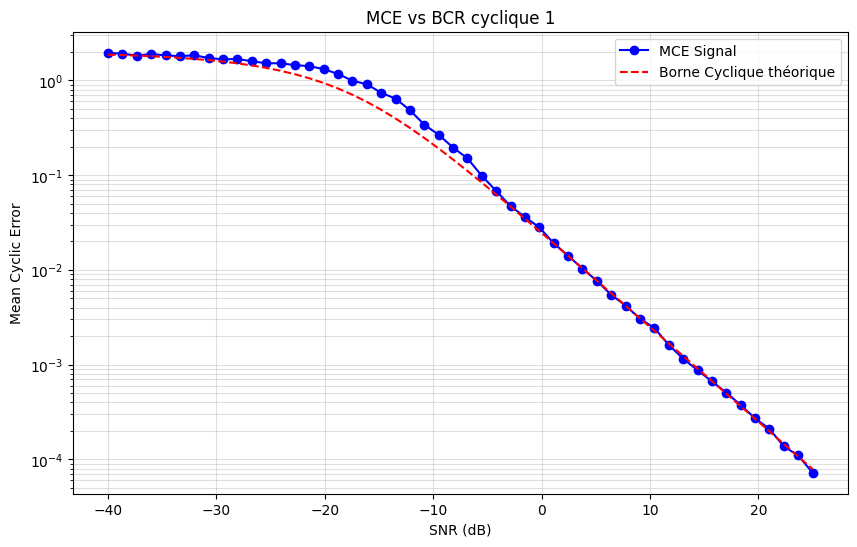

In [7]:
# Tracé de la MCE et de la BCR cyclique dans le cas de l'estimation de la phase

SNR_dB_range = np.linspace(-40, 25, 50) 

mce_simu_sig = []
borne_cyclique_sig = []

print("Calcul de la MCE du signal en cours...")

for snr_db in SNR_dB_range:
    snr = 10 ** (snr_db / 10)
    sigma = np.sqrt(A**2 / snr)
    
    errors_iter = []
    n = np.arange(N)

    s_vrai = A * np.exp(1j * (n * omega0_ref + phi))
    
    for _ in range(N_MC):

        x = generer_signal(N, omega0_ref, sigma)
        phi_hat = estimer_phi(x, omega0_ref)
        
        s_hat = A * np.exp(1j * (n * omega0_ref + phi_hat))
        mce = np.mean(2 * (1 - np.cos(phi_hat - phi)))

        errors_iter.append(mce)
    
    mce_simu_sig.append(np.mean(errors_iter))
    
    bcr_sig_classique = (sigma**2) / 2
    bcr_phi = (sigma**2) / (2*N*A)
    

    val_borne = (2 - 2 / np.sqrt(1 + bcr_phi))
    borne_cyclique_sig.append(val_borne)


plt.figure(figsize=(10, 6))
plt.semilogy(SNR_dB_range, mce_simu_sig, 'bo-', label='MCE Signal')
plt.semilogy(SNR_dB_range, borne_cyclique_sig, 'r--', label='Borne Cyclique théorique')

plt.xlabel('SNR (dB)')
plt.ylabel('Mean Cyclic Error')
plt.title('MCE vs BCR cyclique 1')
plt.grid(True, which='both', alpha=0.4)
plt.legend()
plt.show()

## Echantillonnage irrégulier

In [ ]:
# ==============================================================
#  FONCTIONS IRRÉGULIÈRES — même logique, t remplace np.arange(N)
# ==============================================================
 
def generer_signal_irr(t, omega_true, sigma):
    # Identique à generer_signal mais évaluée sur les instants t
    s     = A * np.exp(1j * (t * omega_true + phi))
    bruit = (sigma / np.sqrt(2)) * (np.random.randn(len(t)) + 1j * np.random.randn(len(t)))
    return s + bruit
 
def estimer_omega_irr(x, t):
    # Identique à estimer_omega mais n -> t
    projection_grille = np.dot(x, np.exp(-1j * np.outer(t, omega_grid)))
    vals = np.real(np.exp(-1j * phi) * projection_grille)
    
    idx_max = np.argmax(vals)
    omega_initial = omega_grid[idx_max]

    # 2. Raffinement local (Précis)
    def objective(w):

        term_somme = np.sum(x * np.exp(-1j * t * w))
        return -np.real(np.exp(-1j * phi) * term_somme)
    
    pas = (omega_grid[1] - omega_grid[0])
    res = minimize_scalar(objective, 
                          bounds=(omega_initial - pas, omega_initial + pas), 
                          method='bounded',
                          options={'xatol': 1e-12}) 
    
    
    return res.x
 
def estimer_phi_irr(x, t, omega):
    # Identique à estimer_phi mais n -> t
    projection = np.sum(x * np.exp(-1j * t * omega))
    return np.angle(projection)
 
def BCR_irr(t, sigma):
    sum_t2 = np.sum(t ** 2)
    return sigma ** 2 / (np.sum(t**2)*2*A ** 2)
 
def monte_carlo_irr(t, omega_true, sigma):
    # Identique à monte_carlo mais utilise les fonctions irrégulières
    estimations = []
    for _ in range(N_MC):
        x = generer_signal_irr(t, omega_true, sigma)
        omega_hat = estimer_omega_irr(x, t)
        estimations.append(omega_hat)
    estimations = np.array(estimations)
    biais    = np.mean(estimations) - omega_true
    variance = np.var(estimations)
    mse      = np.mean((estimations - omega_true) ** 2)
    return biais, variance, mse

# Estimation de omega avec un échantillonnage irrégulier

In [69]:
A          = 1.0
phi        = 0.5
omega0_ref = 1.0
N          = 20      # nombre de points de la grille régulière de base
M          = 10      # nombre de points qu'on garde (M < N)
N_MC       = 300
SNR_dB     = 10.0
omega_grid = np.linspace(-np.pi, np.pi, 1000)
 
# Tirage des instants irréguliers (fait une seule fois, fixé pour tous les sweeps)
np.random.seed(42)
t_irr = np.sort(np.random.choice(N, size=M, replace=False))
print(f"Instants retenus ({M}/{N}) : {t_irr}")

Instants retenus (10/20) : [ 0  1  3  5  8 11 15 16 17 18]


Sweep SNR (irrégulier)...


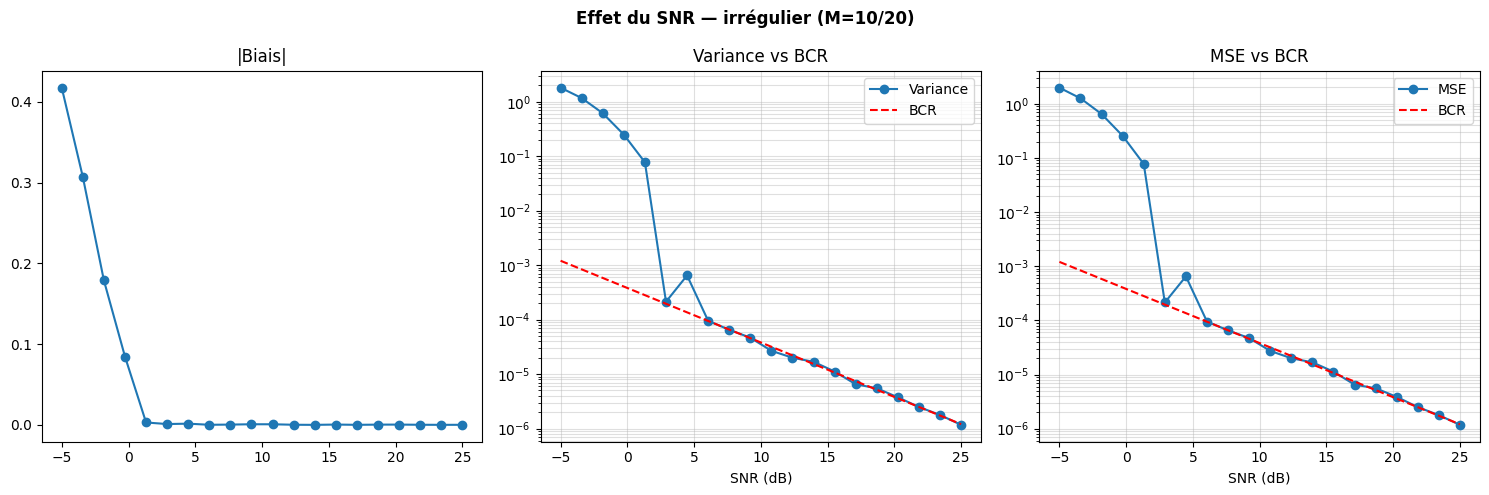

In [54]:
SNR_dB_values = np.linspace(-5, 25, 20)
biais_snr, variance_snr, mse_snr, bcr_snr = [], [], [], []
 
print("Sweep SNR (irrégulier)...")
for snr_db in SNR_dB_values:
    snr   = 10 ** (snr_db / 10)
    sigma = np.sqrt(A ** 2 / snr)
    b, v, m = monte_carlo_irr(t_irr, omega0_ref, sigma)
    biais_snr.append(abs(b))
    variance_snr.append(v)
    mse_snr.append(m)
    bcr_snr.append(BCR_irr(t_irr, sigma))
    # bcr_snr.append(BCR(N,sigma))
 
fig1, axes1 = plt.subplots(1, 3, figsize=(15, 5))
fig1.suptitle(f"Effet du SNR — irrégulier (M={M}/{N})", fontweight='bold')
 
axes1[0].plot(SNR_dB_values, biais_snr, 'o-')
axes1[0].set_title("|Biais|")
 
tracer(axes1[1], SNR_dB_values, variance_snr, bcr_snr, "SNR (dB)", "Variance", "Variance vs BCR")
tracer(axes1[2], SNR_dB_values, mse_snr,      bcr_snr, "SNR (dB)", "MSE",      "MSE vs BCR")
 
fig1.tight_layout()
plt.show()

Calcul de la MSE (Irrégulier)...


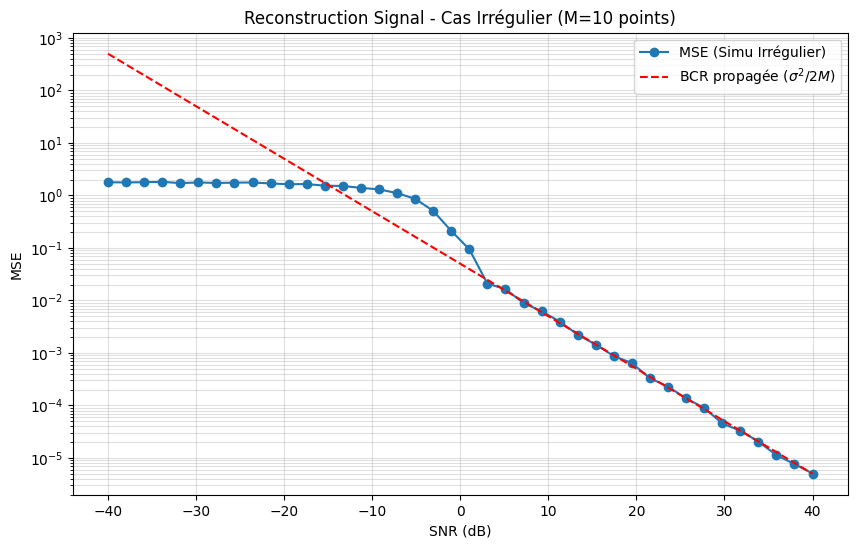

In [ ]:
# --- MSE DE RECONSTRUCTION (CAS IRRÉGULIER) --- joana.m.frontera@hotmail.com

SNR_dB_range = np.linspace(-40, 40, 40) 
mse_estimation_irr = []
bcr_propagation_irr = []

print("Calcul de la MSE (Irrégulier)...")

for snr_db in SNR_dB_range:
    snr = 10 ** (snr_db / 10)
    sigma = np.sqrt(A**2 / snr)
    
    errors_iter = []
    s_vrai = A * np.exp(1j * (t_irr * omega0_ref + phi))
    
    for _ in range(N_MC):
        x = generer_signal_irr(t_irr, omega0_ref, sigma)
        omega_hat = estimer_omega_irr(x, t_irr)
        s_hat = A * np.exp(1j * (t_irr * omega_hat + phi))
        errors_iter.append(np.mean(np.abs(s_vrai - s_hat)**2))
    
    mse_estimation_irr.append(np.mean(errors_iter))
    
    # La borne théorique
    borne_sig_irr = sigma**2 / (2 * M)
    bcr_propagation_irr.append(borne_sig_irr)

# --- Affichage avec Raw Strings pour éviter les SyntaxWarning ---
fig_irr, ax_irr = plt.subplots(1, 1, figsize=(10, 6))
ax_irr.semilogy(SNR_dB_range, mse_estimation_irr, 'o-', label="MSE (Simu Irrégulier)")

# Utilisation du r"..." ici pour sigma
ax_irr.semilogy(SNR_dB_range, bcr_propagation_irr, 'r--', label=r"BCR propagée ($\sigma^2/2M$)")

ax_irr.set_xlabel("SNR (dB)")
ax_irr.set_ylabel("MSE")
ax_irr.set_title(f"Reconstruction Signal - Cas Irrégulier (M={M} points)")
ax_irr.legend()
ax_irr.grid(True, which='both', alpha=0.4)

plt.show()

Calcul de la MCE (irrégulier)...


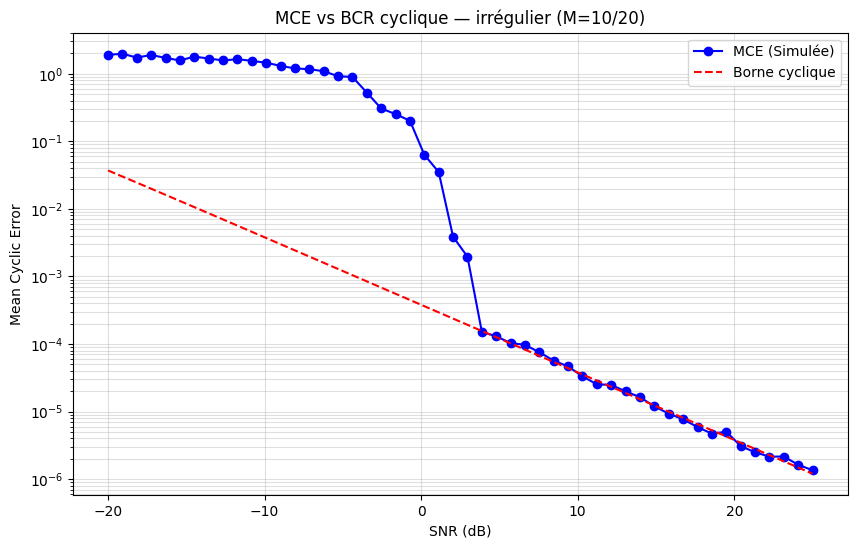

Done.


In [73]:
SNR_dB_range   = np.linspace(-20, 25, 50)
mce_simu_sig   = []
borne_cyclique_sig = []
 
print("Calcul de la MCE (irrégulier)...")
 
for snr_db in SNR_dB_range:
    snr   = 10 ** (snr_db / 10)
    sigma = np.sqrt(A ** 2 / snr)
 
    errors_iter = []
 
    for _ in range(N_MC):
        x         = generer_signal_irr(t_irr, omega0_ref, sigma)
        omega_hat = estimer_omega_irr(x, t_irr)
 
        mce = 2 * (1 - np.cos(omega_hat - omega0_ref))   # identique à l'original
        errors_iter.append(mce)
 
    mce_simu_sig.append(np.mean(errors_iter))
 
    bcr_omega    = BCR_irr(t_irr, sigma)                  # seul changement vs original
    bcr_cyclique = 2 - 2 / np.sqrt(1 + bcr_omega)
    borne_cyclique_sig.append(bcr_cyclique)
 
plt.figure(figsize=(10, 6))
plt.semilogy(SNR_dB_range, mce_simu_sig,       'bo-', label='MCE (Simulée)')
plt.semilogy(SNR_dB_range, borne_cyclique_sig, 'r--', label='Borne cyclique')
plt.xlabel('SNR (dB)')
plt.ylabel('Mean Cyclic Error')
plt.title(f'MCE vs BCR cyclique — irrégulier (M={M}/{N})')
plt.grid(True, which='both', alpha=0.4)
plt.legend()
plt.show()
 
print("Done.")

# Comparaison des modèles #

Calcul MSE Régulier...
Calcul MSE Irrégulier...


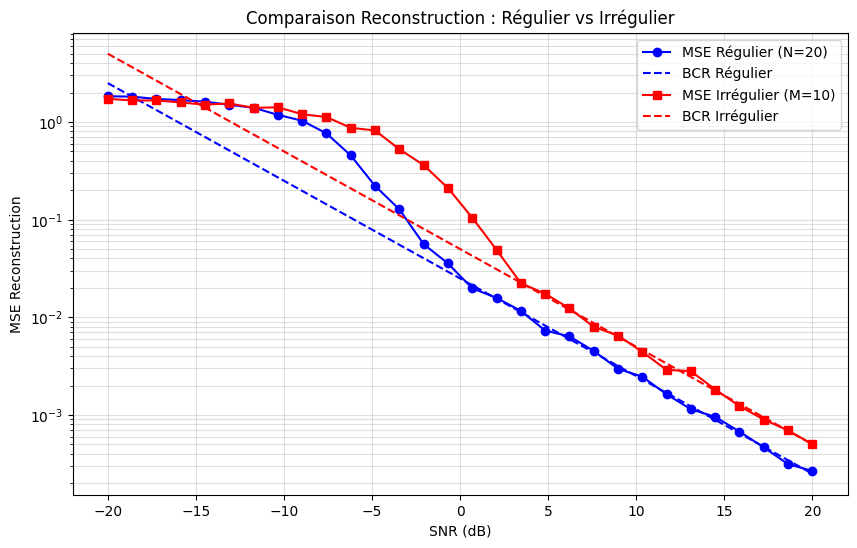

In [75]:
# --- 1. Simulation Cas RÉGULIER ---
SNR_dB_range = np.linspace(-20, 20, 30)
mse_reg = []
bcr_sig_reg = []

print("Calcul MSE Régulier...")
for snr_db in SNR_dB_range:
    snr = 10 ** (snr_db / 10)
    sigma = np.sqrt(A**2 / snr)
    
    errors_iter = []
    n = np.arange(N)
    s_vrai = A * np.exp(1j * (n * omega0_ref + phi))
    
    for _ in range(N_MC):
        x = generer_signal(N, omega0_ref, sigma)
        omega_hat = estimer_omega(x) # Ta fonction existante
        s_hat = A * np.exp(1j * (n * omega_hat + phi))
        errors_iter.append(np.mean(np.abs(s_vrai - s_hat)**2))
    
    mse_reg.append(np.mean(errors_iter))
    bcr_sig_reg.append(sigma**2 / (2 * N))

# --- 2. Simulation Cas IRRÉGULIER ---
mse_irr = []
bcr_sig_irr = []

print("Calcul MSE Irrégulier...")
for snr_db in SNR_dB_range:
    snr = 10 ** (snr_db / 10)
    sigma = np.sqrt(A**2 / snr)
    
    errors_iter = []
    s_vrai_irr = A * np.exp(1j * (t_irr * omega0_ref + phi))
    
    for _ in range(N_MC):
        x = generer_signal_irr(t_irr, omega0_ref, sigma)
        omega_hat = estimer_omega_irr(x, t_irr) # Ta fonction existante
        s_hat = A * np.exp(1j * (t_irr * omega_hat + phi))
        errors_iter.append(np.mean(np.abs(s_vrai_irr - s_hat)**2))
    
    mse_irr.append(np.mean(errors_iter))
    # Ta formule de borne propagée pour l'irrégulier
    borne_sig_irr = sigma**2/(2*M)
    bcr_sig_irr.append(borne_sig_irr)

# --- 3. Tracé Superposé ---
fig, ax = plt.subplots(figsize=(10, 6))

# Tracé Régulier (Bleu)
ax.semilogy(SNR_dB_range, mse_reg, 'bo-', label=f"MSE Régulier (N={N})")
ax.semilogy(SNR_dB_range, bcr_sig_reg, 'b--', label="BCR Régulier")

# Tracé Irrégulier (Rouge)
ax.semilogy(SNR_dB_range, mse_irr, 'rs-', label=f"MSE Irrégulier (M={M})")
ax.semilogy(SNR_dB_range, bcr_sig_irr, 'r--', label="BCR Irrégulier")

ax.set_xlabel("SNR (dB)")
ax.set_ylabel("MSE Reconstruction")
ax.set_title("Comparaison Reconstruction : Régulier vs Irrégulier")
ax.legend()
ax.grid(True, which='both', alpha=0.4)

plt.show()

# Impact de la variance dans l'échantillonnage sur les résultas

Simulation : Faible Var (var=9.8)...
Simulation : Moyenne Var (var=27.0)...
Simulation : Forte Var (var=61.9)...


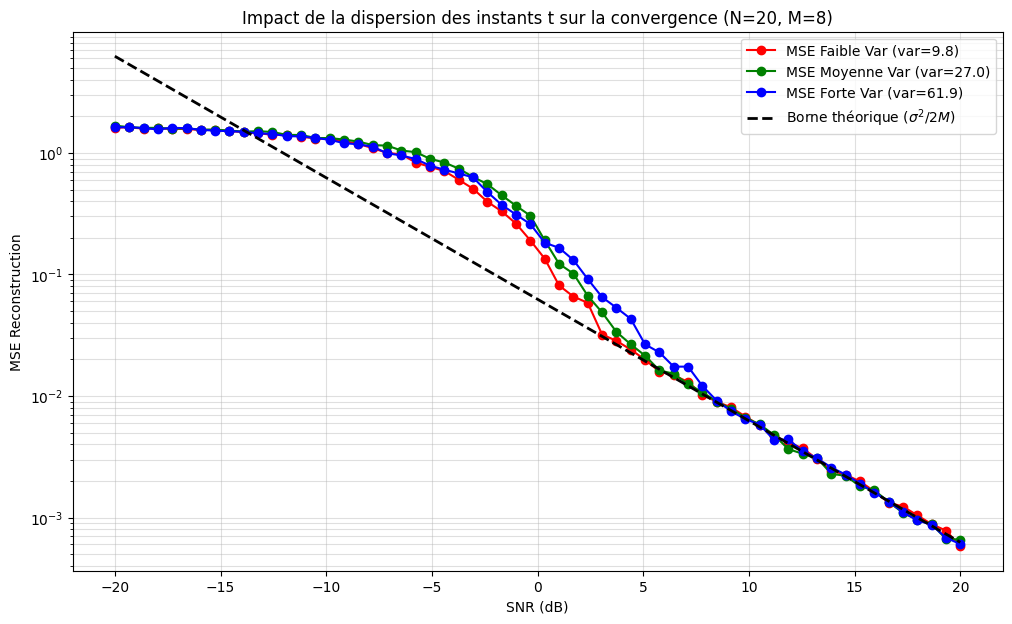

In [87]:
import numpy as np
import matplotlib.pyplot as plt

# --- Paramètres ---
N = 20
M = 8  
A = 1
phi = np.pi/4
omega0_ref = 0.5
N_MC = 1000
SNR_dB_range = np.linspace(-20, 20, 60)
omega_grid = np.linspace(-np.pi, np.pi, 1000) # Assure-toi qu'il est défini

# --- Génération de scénarios ---
np.random.seed(42) # Pour la reproductibilité
t_low_var = np.sort(np.random.choice(np.arange(N//2), size=M, replace=False))
t_mid_var = np.sort(np.random.choice(np.arange(N), size=M, replace=False))
t_high_var = np.sort(np.concatenate([
    np.random.choice(np.arange(5), size=M//2, replace=False),
    np.random.choice(np.arange(N-5, N), size=M//2, replace=False)
]))

scenarios = [
    {'t': t_low_var,  'label': f'Faible Var (var={np.var(t_low_var):.1f})', 'color': 'red'},
    {'t': t_mid_var,  'label': f'Moyenne Var (var={np.var(t_mid_var):.1f})', 'color': 'green'},
    {'t': t_high_var, 'label': f'Forte Var (var={np.var(t_high_var):.1f})', 'color': 'blue'}
]

plt.figure(figsize=(12, 7))

# --- Boucle sur les scénarios ---
for sce in scenarios:
    t_curr = sce['t']
    mse_signal = []
    
    print(f"Simulation : {sce['label']}...")
    
    for snr_db in SNR_dB_range:
        snr = 10 ** (snr_db / 10)
        sigma = np.sqrt(A**2 / snr)
        
        errors_iter = []
        s_vrai = A * np.exp(1j * (t_curr * omega0_ref + phi))
        
        for _ in range(N_MC):
            x = generer_signal_irr(t_curr, omega0_ref, sigma)
            w_hat = estimer_omega_irr(x, t_curr) 
            
            s_hat = A * np.exp(1j * (t_curr * w_hat + phi))
            errors_iter.append(np.mean(np.abs(s_vrai - s_hat)**2))
        
        mse_signal.append(np.mean(errors_iter))

    # Tracé des MSE de simulation
    plt.semilogy(SNR_dB_range, mse_signal, 'o-', color=sce['color'], label=f"MSE {sce['label']}")

# --- Ajout de la borne unique (sigma^2 / 2M) ---
# On la calcule sur la même plage de SNR
sigmas_range = np.sqrt(A**2 / (10 ** (SNR_dB_range / 10)))
bcr_unique = (sigmas_range**2) / (2 * M)

plt.semilogy(SNR_dB_range, bcr_unique, 'k--', linewidth=2, label=r"Borne théorique ($\sigma^2/2M$)")

plt.xlabel("SNR (dB)")
plt.ylabel("MSE Reconstruction")
plt.title(f"Impact de la dispersion des instants t sur la convergence (N={N}, M={M})")
plt.legend()
plt.grid(True, which='both', alpha=0.4)
plt.show()

# Impact du placement dans l'échantillonnage

Simulation : Bloc au début...
Simulation : Bloc au milieu...
Simulation : Bloc à la fin...


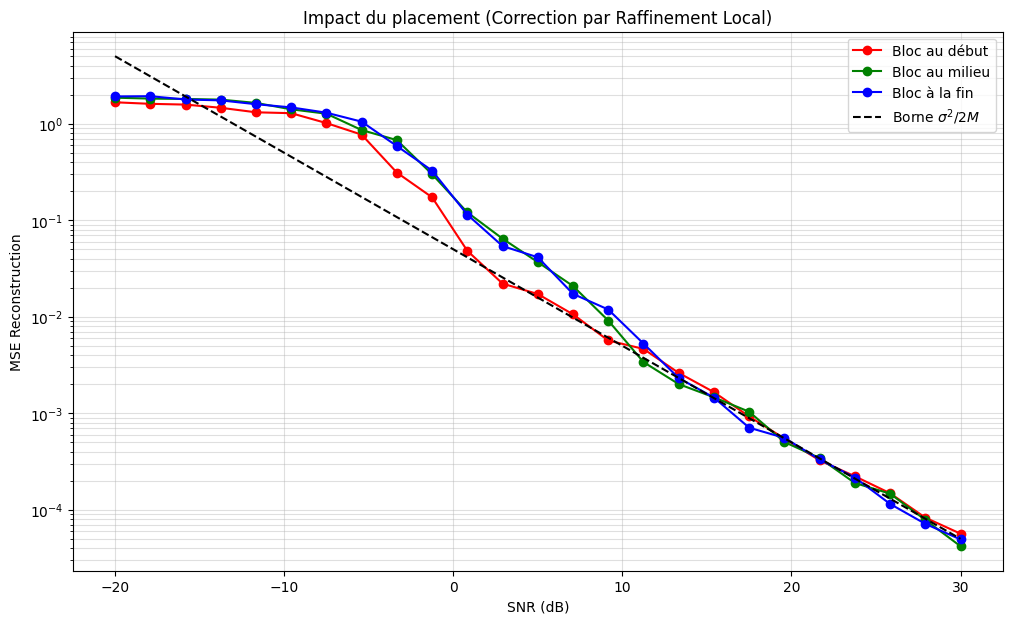

In [109]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

# --- Fonctions Outils ---
def generer_signal_irr(t, omega_true, sigma):
    s = A * np.exp(1j * (t * omega_true + phi))
    bruit = (sigma / np.sqrt(2)) * (np.random.randn(len(t)) + 1j * np.random.randn(len(t)))
    return s + bruit

def estimer_omega_irr(x, t):
    # 1. Recherche grossière sur grille
    omega_grid = np.linspace(-np.pi, np.pi, 1000)
    projection = np.dot(x, np.exp(-1j * np.outer(t, omega_grid)))
    vals = np.real(np.exp(-1j * phi) * projection)
    w_initial = omega_grid[np.argmax(vals)]
    
    # 2. RAFFINEMENT (Pour casser le plancher de saturation)
    # On cherche le maximum réel de manière continue autour de l'estimée grossière
    def objective(w):
        return -np.real(np.exp(-1j * phi) * np.sum(x * np.exp(-1j * t * w)))
    
    # On définit une zone de recherche autour du pic trouvé (ex: +/- le pas de la grille)
    pas = (omega_grid[1] - omega_grid[0])
    res = minimize_scalar(objective, bounds=(w_initial - pas, w_initial + pas), method='bounded')
    return res.x

# --- Paramètres ---
N = 100
M = 10
A = 1
phi = np.pi/4
omega0_ref = 0.5
N_MC = 200 # Réduit légèrement pour compenser le temps de calcul du raffinement
SNR_dB_range = np.linspace(-20, 30, 25) # On monte jusqu'à 30dB pour voir la convergence

# --- Scénarios ---
bloc_base = np.arange(M)
t_debut  = bloc_base
t_milieu = bloc_base + (N // 2 - M // 2)
t_fin    = bloc_base + (N - M)

scenarios = [
    {'t': t_debut,  'label': 'Bloc au début', 'color': 'red'},
    {'t': t_milieu, 'label': 'Bloc au milieu', 'color': 'green'},
    {'t': t_fin,    'label': 'Bloc à la fin', 'color': 'blue'}
]

plt.figure(figsize=(12, 7))

for sce in scenarios:
    t_curr = sce['t']
    mse_signal = []
    print(f"Simulation : {sce['label']}...")
    
    for snr_db in SNR_dB_range:
        snr = 10 ** (snr_db / 10)
        sigma = np.sqrt(A**2 / snr)
        
        errors_iter = []
        s_vrai = A * np.exp(1j * (t_curr * omega0_ref + phi))
        
        for _ in range(N_MC):
            x = generer_signal_irr(t_curr, omega0_ref, sigma)
            w_hat = estimer_omega_irr(x, t_curr) 
            
            s_hat = A * np.exp(1j * (t_curr * w_hat + phi))
            errors_iter.append(np.mean(np.abs(s_vrai - s_hat)**2))
        
        mse_signal.append(np.mean(errors_iter))

    plt.semilogy(SNR_dB_range, mse_signal, 'o-', color=sce['color'], label=sce['label'])

# --- Borne théorique ---
sigmas_range = np.sqrt(A**2 / (10 ** (SNR_dB_range / 10)))
plt.semilogy(SNR_dB_range, (sigmas_range**2)/(2*M), 'k--', label=r"Borne $\sigma^2/2M$")

plt.xlabel("SNR (dB)")
plt.ylabel("MSE Reconstruction")
plt.title("Impact du placement (Correction par Raffinement Local)")
plt.legend()
plt.grid(True, which='both', alpha=0.4)
plt.show()

--- Glouton Monotone (Optimisation MSE @ 5.0dB) ---
Étape 2 : Ajout t= 1 | MSE = 2.38e-01
Étape 3 : Ajout t= 2 | MSE = 8.11e-02
Étape 4 : Ajout t=10 | MSE = 4.29e-02
Étape 5 : Ajout t=11 | MSE = 3.66e-02
Étape 6 : Ajout t=13 | MSE = 9.22e-03
Étape 7 : Ajout t=15 | MSE = 1.50e-03
Étape 8 : Ajout t=16 | MSE = 1.86e-04
Étape 9 : Ajout t=18 | MSE = 1.35e-04
Étape 10 : Ajout t=19 | MSE = 1.14e-04


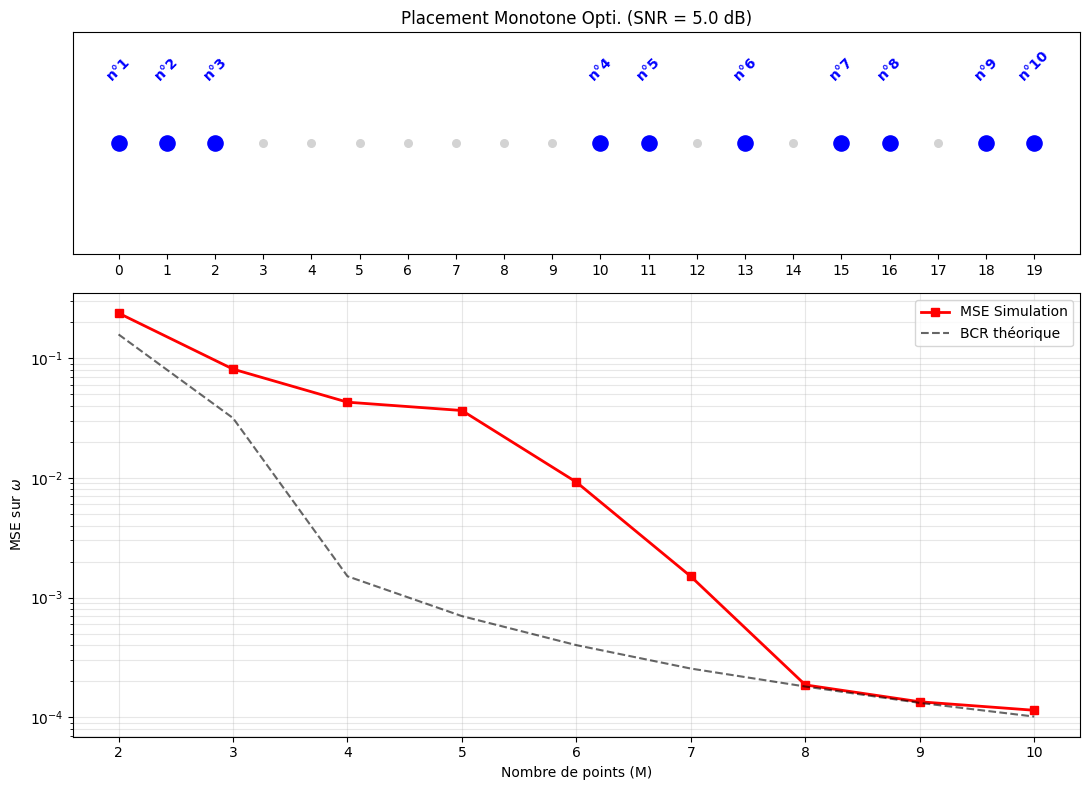

In [129]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

# --- Paramètres ---
N = 20
M = 10
A = 1.0
phi = 0.5
omega0_ref = 1.0
SNR_cible = 5.0  # À 15dB, on doit être parfaitement sur la borne
sigma_test = np.sqrt(A**2 / (10**(SNR_cible/10)))

# On augmente la grille pour plus de robustesse
omega_grid = np.linspace(-np.pi, np.pi, 3000) 

def simuler_mse_point(set_points, sigma, N_MC_glouton=400):
    t = np.array(set_points)
    errors = []
    for _ in range(N_MC_glouton):
        s = A * np.exp(1j * (t * omega0_ref + phi))
        bruit = (sigma / np.sqrt(2)) * (np.random.randn(len(t)) + 1j * np.random.randn(len(t)))
        x = s + bruit
        
        # Recherche sur grille
        proj = np.dot(x, np.exp(-1j * np.outer(t, omega_grid)))
        vals = np.real(np.exp(-1j * phi) * proj)
        w_init = omega_grid[np.argmax(vals)]
        
        # Raffinement local serré (Crucial pour la précision)
        res = minimize_scalar(lambda w: -np.real(np.exp(-1j * phi) * np.sum(x * np.exp(-1j * t * w))),
                              bounds=(w_init-0.1, w_init+0.1), method='bounded')
        errors.append((res.x - omega0_ref)**2)
    return np.mean(errors)

# --- Algorithme Glouton Monotone ---
instants_choisis = [0] 
historique_mse = [float('nan')]

print(f"--- Glouton Monotone (Optimisation MSE @ {SNR_cible}dB) ---")

for i in range(M-1):
    scores_mse = []
    candidats = []
    
    dernier_t = instants_choisis[-1]
    places_restantes = (M - 1) - i
    limite_haute = N - places_restantes
    
    instants_possibles = list(range(dernier_t + 1, limite_haute + 1))
    
    if not instants_possibles: break

    for t_cand in instants_possibles:
        test_set = instants_choisis + [t_cand]
        # On évalue la performance réelle
        mse_reelle = simuler_mse_point(test_set, sigma_test)
        scores_mse.append(mse_reelle)
        candidats.append(t_cand)
        
    meilleur_idx = np.argmin(scores_mse)
    choix = candidats[meilleur_idx]
    mse_val = scores_mse[meilleur_idx]
    
    instants_choisis.append(choix)
    historique_mse.append(mse_val)
    
    print(f"Étape {i+2} : Ajout t={choix:2d} | MSE = {mse_val:.2e}")

# --- Affichage ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), gridspec_kw={'height_ratios': [1, 2]})

# Placement
ax1.scatter(range(N), np.zeros(N), color='lightgray', s=30)
ax1.scatter(instants_choisis, np.zeros(len(instants_choisis)), color='blue', s=120)
for ordre, t in enumerate(instants_choisis):
    ax1.annotate(f"n°{ordre+1}", (t, 0.03), ha='center', va='bottom', fontweight='bold', color='blue', rotation=45)
ax1.set_title(f"Placement Monotone Opti. (SNR = {SNR_cible} dB)")
ax1.set_yticks([]); ax1.set_xticks(range(N))

# MSE vs BCR
ax2.semilogy(range(1, len(instants_choisis)+1), historique_mse, 's-r', linewidth=2, label="MSE Simulation")
bcr_vals = [(sigma_test**2)/(2*A**2*np.sum(np.array(instants_choisis[:k])**2)) if k>1 else np.nan for k in range(1, len(instants_choisis)+1)]
ax2.semilogy(range(1, len(instants_choisis)+1), bcr_vals, '--k', alpha=0.6, label=r"BCR théorique")

ax2.set_xlabel("Nombre de points (M)")
ax2.set_ylabel(r"MSE sur $\omega$")
ax2.legend()
ax2.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

Simulation en cours avec ta formule de borne...


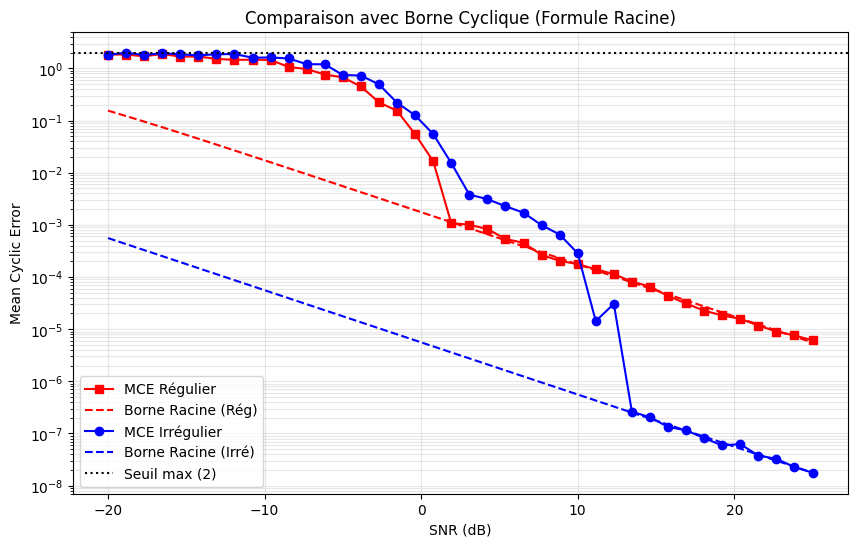

In [124]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

# --- Paramètres inchangés ---
N = 100
M = 10
A = 1
phi = np.pi/4
omega0_ref = 0.5
N_MC = 300
SNR_dB_range = np.linspace(-20, 25, 40)

t_reg = np.arange(M)
t_irr = np.arange(N - M, N)

mce_reg = []
mce_irr = []
borne_reg = []
borne_irr = []

print("Simulation en cours avec ta formule de borne...")

for snr_db in SNR_dB_range:
    snr = 10 ** (snr_db / 10)
    sigma = np.sqrt(A**2 / snr)
    
    # --- 1. Simulations ---
    err_reg = []
    err_irr = []
    for _ in range(N_MC):
        # Cas Régulier
        x_r = generer_signal(M, omega0_ref, sigma)
        w_r = estimer_omega(x_r)
        err_reg.append(2 * (1 - np.cos(w_r - omega0_ref)))
        
        # Cas Irrégulier
        x_i = generer_signal_irr(t_irr, omega0_ref, sigma)
        w_i = estimer_omega_irr(x_i, t_irr)
        err_irr.append(2 * (1 - np.cos(w_i - omega0_ref)))
        
    mce_reg.append(np.mean(err_reg))
    mce_irr.append(np.mean(err_irr))

    # --- 2. Calcul des Bornes avec TA formule ---
    # Pour le Régulier
    bw_reg = BCR(M, sigma)
    borne_reg.append(2 - 2 / np.sqrt(1 + bw_reg))
    
    # Pour l'Irrégulier
    bw_irr = BCR_irr(t_irr, sigma)
    borne_irr.append(2 - 2 / np.sqrt(1 + bw_irr))

# --- Graphique ---
plt.figure(figsize=(10, 6))
plt.semilogy(SNR_dB_range, mce_reg, 's-', color='red', label='MCE Régulier')
plt.semilogy(SNR_dB_range, borne_reg, '--', color='red', label='Borne Racine (Rég)')

plt.semilogy(SNR_dB_range, mce_irr, 'o-', color='blue', label='MCE Irrégulier')
plt.semilogy(SNR_dB_range, borne_irr, '--', color='blue', label='Borne Racine (Irré)')

plt.axhline(y=2, color='k', linestyle=':', label='Seuil max (2)')
plt.xlabel('SNR (dB)')
plt.ylabel('Mean Cyclic Error')
plt.title('Comparaison avec Borne Cyclique (Formule Racine)')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.show()

Simulation : Basse Var (Bloc début) (Var(t) = 8.2)
Simulation : Var Moyenne (Régulier) (Var(t) = 998.2)
Simulation : Haute Var (Split) (Var(t) = 2258.2)


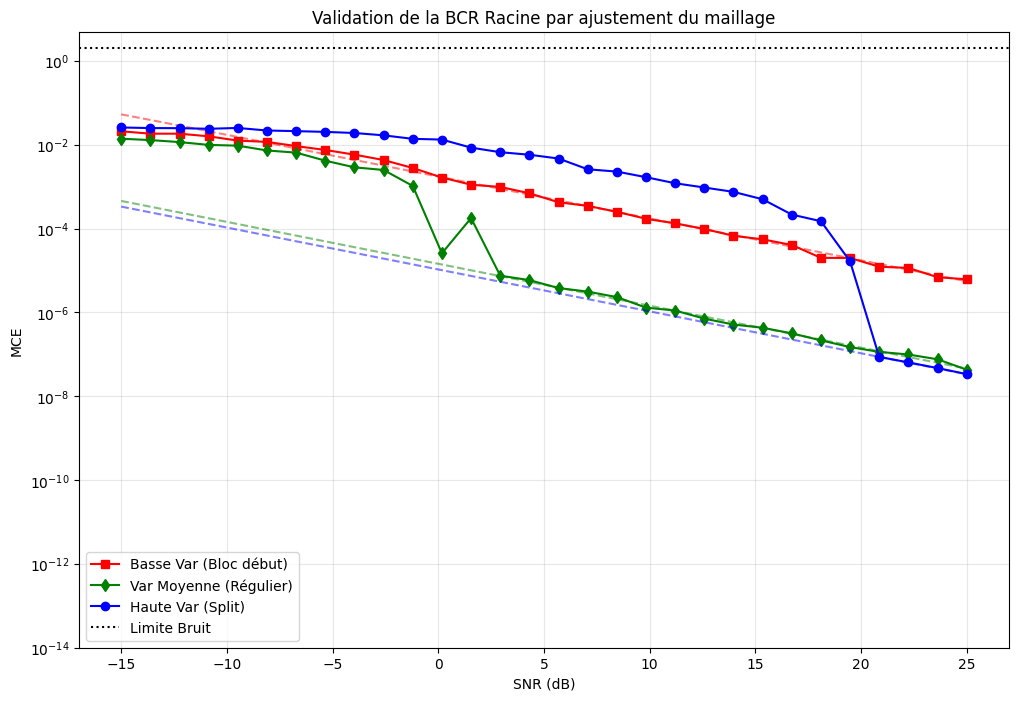

In [125]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

# --- Paramètres globaux ---
N = 100
M = 10
A = 1.0
phi = np.pi/4
omega0_ref = 0.5
N_MC = 250 # Un peu moins pour compenser la grille plus dense
SNR_dB_range = np.linspace(-15, 25, 30)

# Scénarios
t_low_var = np.arange(M) 
t_mid_var = np.linspace(0, N-1, M)
t_high_var = np.concatenate([np.arange(M//2), np.arange(N - M//2, N)])

scenarios = [
    {'t': t_low_var,  'label': 'Basse Var (Bloc début)', 'color': 'red',   'marker': 's'},
    {'t': t_mid_var,  'label': 'Var Moyenne (Régulier)', 'color': 'green', 'marker': 'd'},
    {'t': t_high_var, 'label': 'Haute Var (Split)',      'color': 'blue',  'marker': 'o'}
]

def estimer_omega_complet(x, t, phi_known):
    # --- CORRECTION DU MAILLAGE ---
    # La largeur du pic est inversement proportionnelle à max(t)
    t_max = np.max(t)
    # On définit une grille dont la densité dépend de t_max
    # Pour t_max=100, il faut au moins 5000-8000 points pour ne pas rater le pic
    n_points = int(200 * t_max) if t_max > 0 else 2000
    n_points = max(n_points, 2000) # Sécurité minimum
    
    grid = np.linspace(omega0_ref - 0.2, omega0_ref + 0.2, n_points)
    
    # Projection sur la grille locale autour de la vérité (pour la simu)
    # ou sur [-pi, pi] si on veut être réaliste, mais ici on veut vérifier la BCR
    proj = np.dot(x, np.exp(-1j * np.outer(t, grid)))
    vals = np.real(np.exp(-1j * phi_known) * proj)
    w_init = grid[np.argmax(vals)]
    
    # Raffinement très serré
    def obj(w):
        return -np.real(np.exp(-1j * phi_known) * np.sum(x * np.exp(-1j * t * w)))
    
    # Intervalle de recherche du raffinement réduit
    pas_grille = grid[1] - grid[0]
    res = minimize_scalar(obj, bounds=(w_init - pas_grille, w_init + pas_grille), method='bounded')
    return res.x

# --- Simulation ---
plt.figure(figsize=(12, 8))

for sce in scenarios:
    t_curr = sce['t']
    var_t = np.var(t_curr)
    mce_simu = []
    borne_cyc = []
    
    print(f"Simulation : {sce['label']} (Var(t) = {var_t:.1f})")
    
    for snr_db in SNR_dB_range:
        snr = 10 ** (snr_db / 10)
        sigma = np.sqrt(A**2 / snr)
        
        errs = []
        for _ in range(N_MC):
            s = A * np.exp(1j * (t_curr * omega0_ref + phi))
            bruit = (sigma/np.sqrt(2)) * (np.random.randn(M) + 1j*np.random.randn(M))
            x = s + bruit
            
            w_hat = estimer_omega_complet(x, t_curr, phi)
            errs.append(2 * (1 - np.cos(w_hat - omega0_ref)))
            
        mce_simu.append(np.mean(errs))
        
        # Borne Racine
        bcr_w = (sigma**2) / (2 * A**2 * np.sum(t_curr**2))
        borne_cyc.append(2 - 2 / np.sqrt(1 + bcr_w))
        
    plt.semilogy(SNR_dB_range, mce_simu, sce['marker'] + '-', color=sce['color'], label=f"{sce['label']}")
    plt.semilogy(SNR_dB_range, borne_cyc, '--', color=sce['color'], alpha=0.5)

plt.axhline(y=2, color='k', linestyle=':', label='Limite Bruit')
plt.xlabel('SNR (dB)')
plt.ylabel('MCE')
plt.title('Validation de la BCR Racine par ajustement du maillage')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.ylim(1e-14, 5)
plt.show()

Optimisation Gloutonne Monotone MCE @ 5.0 dB...
Étape 2: Ajout t= 1 | MCE = 1.85e-01
Étape 3: Ajout t= 2 | MCE = 6.85e-02
Étape 4: Ajout t= 3 | MCE = 1.09e-02
Étape 5: Ajout t= 7 | MCE = 2.50e-03
Étape 6: Ajout t=18 | MCE = 5.52e-04
Étape 7: Ajout t=34 | MCE = 1.13e-04
Étape 8: Ajout t=64 | MCE = 3.11e-05
Étape 9: Ajout t=84 | MCE = 1.22e-05


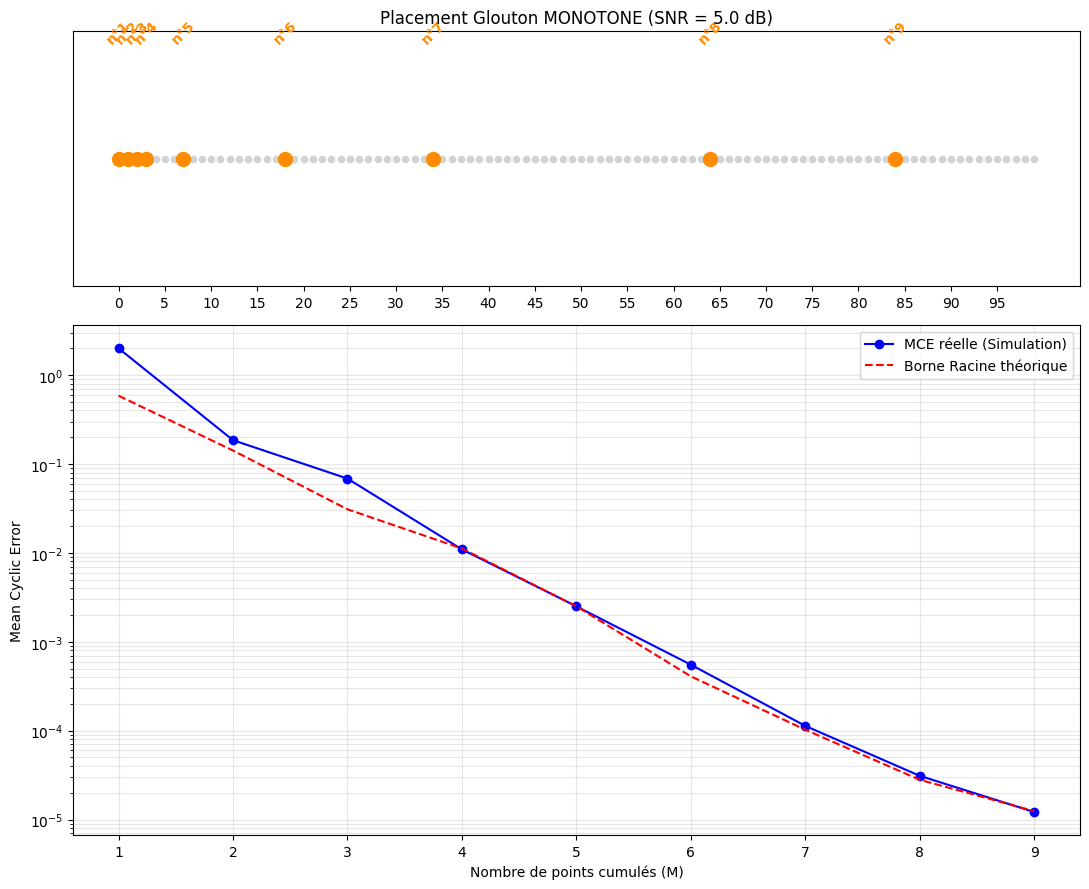

In [132]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

# --- Paramètres de configuration ---
N = 100
M = 9
A = 1.0
phi = np.pi/4
omega0_ref = 0.5
SNR_glouton = 5.0 
sigma_g = np.sqrt(A**2 / (10**(SNR_glouton/10)))
N_MC_glouton = 200 
omega_grid = np.linspace(-np.pi, np.pi, 2000)

def estimer_mce_candidat(set_points, sigma):
    t = np.array(set_points)
    errors = []
    for _ in range(N_MC_glouton):
        s = A * np.exp(1j * (t * omega0_ref + phi))
        bruit = (sigma/np.sqrt(2)) * (np.random.randn(len(t)) + 1j*np.random.randn(len(t)))
        x = s + bruit
        
        proj = np.dot(x, np.exp(-1j * np.outer(t, omega_grid)))
        w_init = omega_grid[np.argmax(np.real(np.exp(-1j * phi) * proj))]
        
        def obj(w):
            return -np.real(np.exp(-1j * phi) * np.sum(x * np.exp(-1j * t * w)))
        
        res = minimize_scalar(obj, bounds=(w_init - 0.1, w_init + 0.1), method='bounded')
        errors.append(2 * (1 - np.cos(res.x - omega0_ref)))
    return np.mean(errors)

# --- Initialisation Gloutonne Monotone ---
instants_choisis = [0] 
historique_mce = [2.0] 

print(f"Optimisation Gloutonne Monotone MCE @ {SNR_glouton} dB...")

for i in range(M - 1):
    scores_mce = []
    candidats = []
    
    # --- CONTRAINTE MONOTONE ---
    dernier_t = instants_choisis[-1]
    # On doit laisser assez de points pour les étapes suivantes 
    # (ex: s'il reste 3 points à choisir, on ne peut pas prendre N-1 tout de suite)
    points_restants_a_choisir = (M - 1) - i
    limite_haute = N - points_restants_a_choisir
    
    # On ne regarde que les instants APRES le dernier choisi
    instants_possibles = list(range(dernier_t + 1, limite_haute + 1))
    
    if not instants_possibles:
        print("Alerte : Plus aucun point disponible respectant la croissance !")
        break

    for t_cand in instants_possibles:
        test_set = instants_choisis + [t_cand]
        mce_val = estimer_mce_candidat(test_set, sigma_g)
        scores_mce.append(mce_val)
        candidats.append(t_cand)
    
    best_idx = np.argmin(scores_mce)
    choix = candidats[best_idx]
    
    instants_choisis.append(choix)
    historique_mce.append(scores_mce[best_idx])
    
    print(f"Étape {i+2}: Ajout t={choix:2d} | MCE = {scores_mce[best_idx]:.2e}")

# --- Calcul de la Borne Racine ---
bcr_omega_final = []
borne_racine_final = []
for k in range(1, len(instants_choisis) + 1):
    sub_set = np.array(instants_choisis[:k])
    bcr_w = (sigma_g**2) / (2 * A**2 * np.sum(sub_set**2)) if k > 1 else 1.0
    borne_racine_final.append(2 - 2 / np.sqrt(1 + bcr_w))

# --- Affichage ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 9), gridspec_kw={'height_ratios': [1, 2]})

# Chronogramme
ax1.scatter(range(N), np.zeros(N), color='lightgray', s=20, label='Disponibles')
ax1.scatter(instants_choisis, np.zeros(len(instants_choisis)), color='darkorange', s=100, zorder=3)
for idx, t in enumerate(instants_choisis):
    ax1.annotate(f"n°{idx+1}", (t, 0.05), ha='center', fontweight='bold', color='darkorange', rotation=45)
ax1.set_title(f"Placement Glouton MONOTONE (SNR = {SNR_glouton} dB)")
ax1.set_yticks([])
ax1.set_xticks(np.arange(0, N, 5))

# Performance
ax2.semilogy(range(1, len(instants_choisis)+1), historique_mce, 'o-', color='blue', label='MCE réelle (Simulation)')
ax2.semilogy(range(1, len(instants_choisis)+1), borne_racine_final, '--r', label='Borne Racine théorique')
ax2.set_xlabel("Nombre de points cumulés (M)")
ax2.set_ylabel("Mean Cyclic Error")
ax2.grid(True, which='both', alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()